In [2]:
import pysindy as ps
from matplotlib import pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp


In [3]:

## Error testing for Lotka Volterra

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=1e-12)
amountOfData = np.arange(6, 5000)
def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

coef_error = np.full(len(amountOfData), np.nan)
success = np.zeros(len(amountOfData))

Xi_true = np.array([
    [0.0,  0.0],   # 1
    [1.1,  0.0],   # x
    [0.0, -0.4],   # y
    [0.0,  0.0],   # x^2
    [-0.4, 0.1],   # xy
    [0.0,  0.0]    # y^2
])
p = 0
for index, count in enumerate(amountOfData):

    params = (1.1, 0.4, 0.4, 0.1)
    initial_pop = [10, 5]

    t_eval = np.linspace(0, 100, count)

    sol = solve_ivp(
        lotka_volterra,
        (0, 100),
        initial_pop,
        args=params,
        t_eval=t_eval
    )

    X = np.stack((sol.y[0], sol.y[1]), axis=-1)

    model = ps.SINDy(
        differentiation_method=differentiation_method,
        feature_library=feature_library,
        optimizer=optimizer,
    )
    try:
        model.fit(X, t=sol.t)
        # print(model.get_feature_names())
        # break
        Xi_hat = model.coefficients().T
        p = len(model.get_feature_names())
        # coef_error[index] = np.linalg.norm(
        #     Xi_true - Xi_hat,
        #     ord="fro"
        # )
        coef_error[index] = (
                np.linalg.norm(Xi_true - Xi_hat, ord="fro")
                / np.linalg.norm(Xi_true, ord="fro")
        )
        success[index] = 1

    except Exception:
        pass
print(p)

6


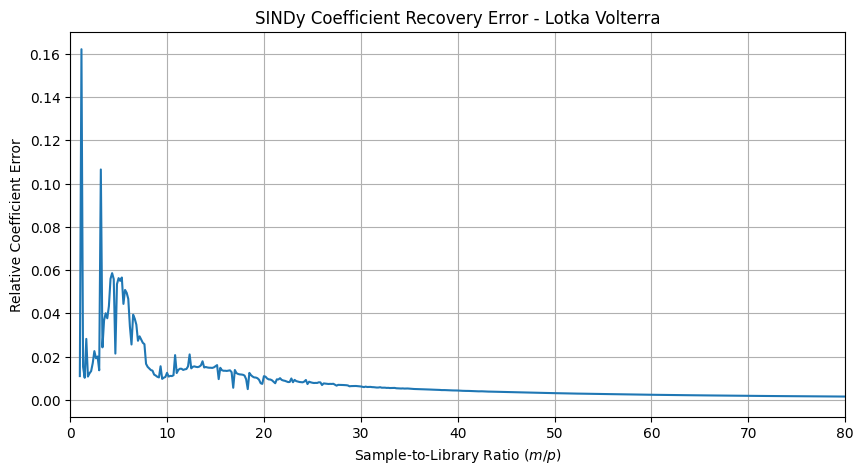

In [11]:

plt.figure(figsize=(10, 5))
plt.plot(amountOfData/p, coef_error/100)
plt.xlabel("Sample-to-Library Ratio ($m/p$)")
plt.ylabel("Relative Coefficient Error")
plt.title("SINDy Coefficient Recovery Error - Lotka Volterra")
plt.xlim(0, 80)
plt.grid(True)
# plt.yscale("log")
plt.show()

$$
\begin{align}
\frac{dx}{dt} &= \sigma (y - x) \\
\frac{dy}{dt} &= x(\rho - z) - y \\
\frac{dz}{dt} &= xy - \beta z
\end{align}
$$
$$
\omega=10,\ \rho=28,\ \beta =\frac{8}{3}
$$
$$
\begin{align}
\frac{dx}{dt} &= 10(y - x) \\
\frac{dy}{dt} &= 28x - xz - y \\
\frac{dz}{dt} &= xy - \frac{8}{3}z
\end{align}
$$

In [5]:
differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=1e-12)
amountOfData = np.arange(6, 5000)

lorenz_p = 0

def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]


coef_error_lorenz = np.full(len(amountOfData), np.nan)

success = np.zeros(len(amountOfData))

Xi_true = np.array([
    [0.0, 0.0, 0.0],          # 1
    [-10.0, 28.0, 0.0],       # x
    [10.0, -1.0, 0.0],        # y
    [0.0, 0.0, -8/3],         # z
    [0.0, 0.0, 0.0],          # x^2
    [0.0, 0.0, 1.0],          # x y
    [0.0, -1.0, 0.0],         # x z
    [0.0, 0.0, 0.0],          # y^2
    [0.0, 0.0, 0.0],          # y z
    [0.0, 0.0, 0.0]           # z^2
])

for index, count in enumerate(amountOfData):
    params = (10.0, 28.0, 8/3)
    initial_pop = [1.0, 1.0, 1.0]
    t_eval = np.linspace(0, 100, count)
    sol = solve_ivp(
        lorenz,
        (0, 100),
        initial_pop,
        args=params,
        t_eval=t_eval
    )
    X = np.stack((sol.y[0], sol.y[1], sol.y[2]), axis=-1)
    model = ps.SINDy(
        differentiation_method=differentiation_method,
        feature_library=feature_library,
        optimizer=optimizer,
    )
    try:
        model.fit(X, t=sol.t)
        Xi_hat = model.coefficients().T
        # coef_error_lorenz[index] = np.linalg.norm(
        #     Xi_true - Xi_hat,
        #     ord="fro"
        # )
        lorenz_p = len(model.get_feature_names())
        coef_error_lorenz[index] = (
                np.linalg.norm(Xi_true - Xi_hat, ord="fro")
                / np.linalg.norm(Xi_true, ord="fro")
        )
        success[index] = 1
    except Exception:
        pass

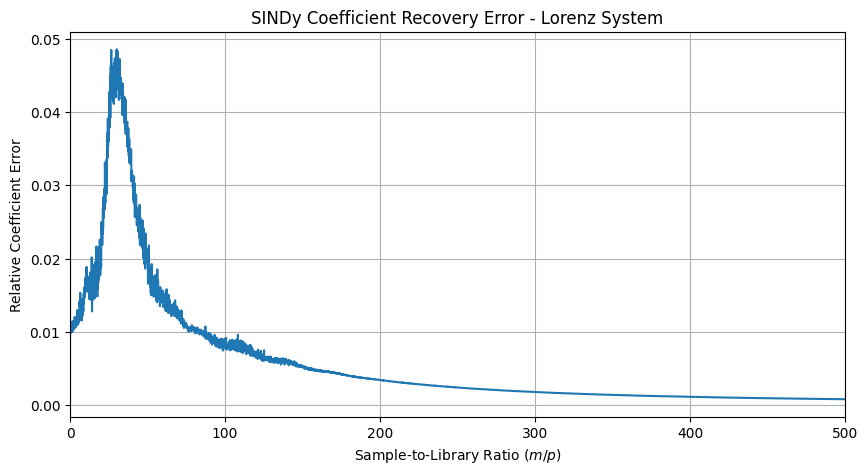

np.int64(296)

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(amountOfData/lorenz_p, coef_error_lorenz/100)
# plt.plot(amountOfData/p, coef_error/100)
plt.xlim(0,500)
plt.xlabel("Sample-to-Library Ratio ($m/p$)")
plt.ylabel("Relative Coefficient Error")
plt.title("SINDy Coefficient Recovery Error - Lorenz System")
plt.grid(True)
# plt.yscale("log")
plt.show()
np.argmax(coef_error_lorenz)